In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.impute import KNNImputer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE


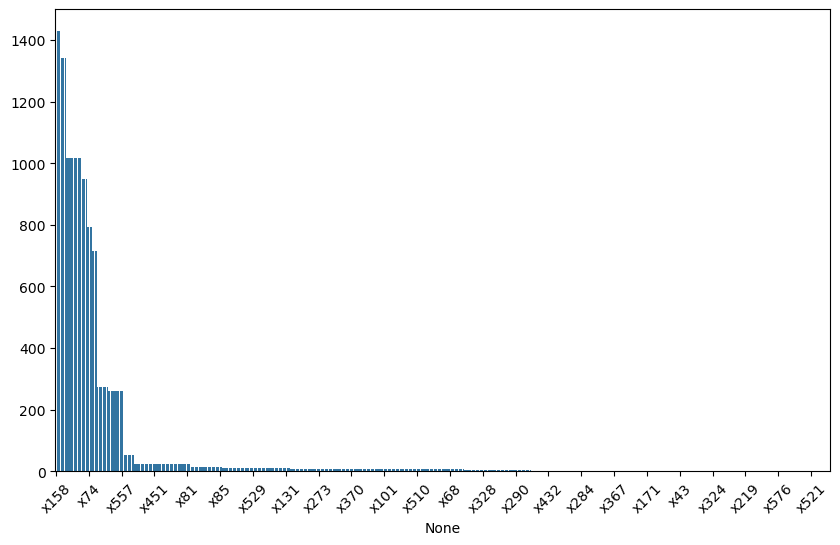

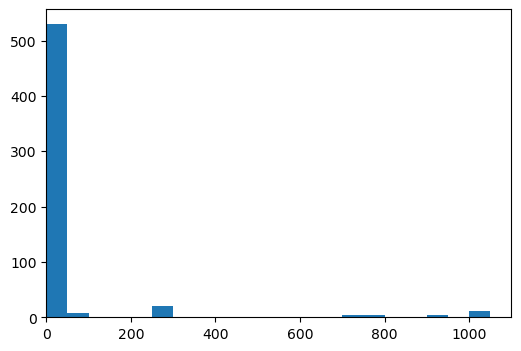

In [2]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=na_counts.index, y=na_counts.values)
plt.xticks(range(0, len(na_counts), 25), na_counts.index[::25], rotation=45)
plt.show()

na_s = X.isna().sum()
plt.figure(figsize=(6, 4))
plt.hist(na_s.values, bins=np.arange(0, 1150, 50))
plt.xlim(0, 1100)
plt.show()

c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


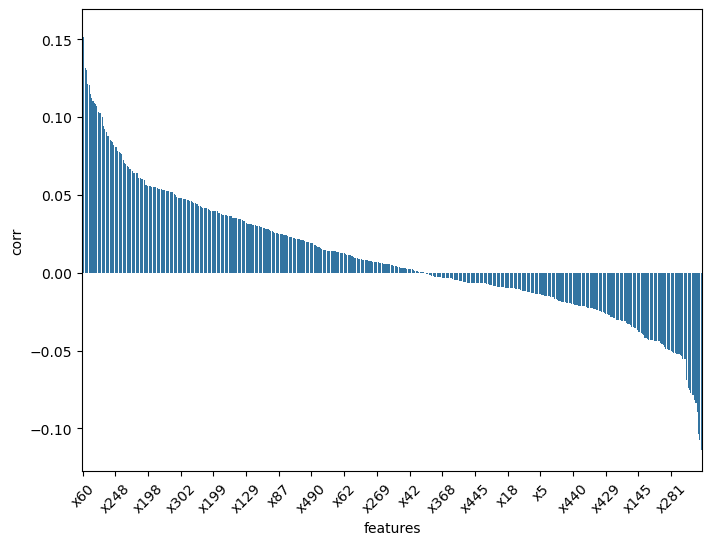

In [3]:
xy_corr = X.corrwith(y).dropna().sort_values(ascending=False)
xy_corr_df = xy_corr.reset_index()
xy_corr_df.columns = ['features', 'corr']
plt.figure(figsize=(8, 6))
sns.barplot(data=xy_corr_df, x='features', y='corr')
plt.xticks(range(0, len(xy_corr), 25), xy_corr.index[::25], rotation=45)
plt.show()

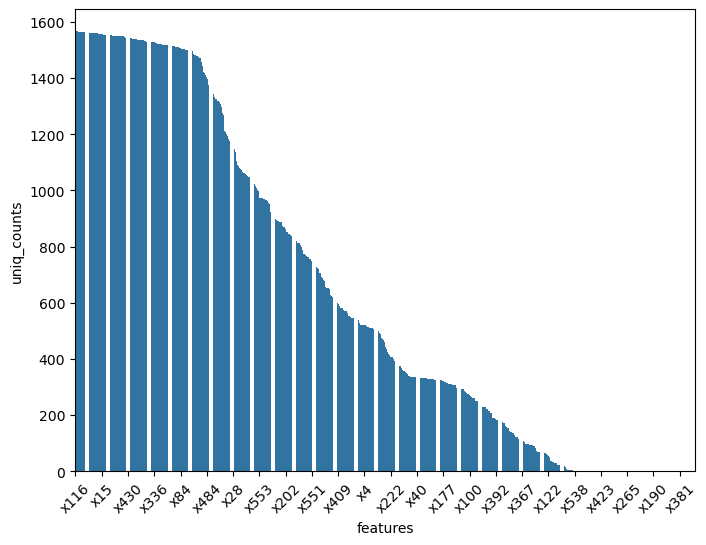

In [4]:
uniq_counts_incl_nas = X.apply(lambda x: x.nunique(dropna=False)).sort_values(ascending=False)
uniq_counts_incl_nas_df = uniq_counts_incl_nas.reset_index()
uniq_counts_incl_nas_df.columns = ['features', 'uniq_counts']
plt.figure(figsize=(8, 6))
sns.barplot(data=uniq_counts_incl_nas_df, x='features', y='uniq_counts')
plt.xticks(range(0, len(uniq_counts_incl_nas), 25), uniq_counts_incl_nas.index[::25], rotation=45)
plt.show()

---
---

In [4]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pipe = Pipeline([
    ("imp", KNNImputer(n_neighbors=10, weights="distance")),
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000))])
Cs = np.logspace(3, -4, 40)
gcv = GridSearchCV(pipe, {"lr__C": Cs}, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="roc_auc", n_jobs=-1, refit=True)
gcv.fit(X_train, y_train)

best_C = gcv.best_params_["lr__C"]
coef = gcv.best_estimator_.named_steps["lr"].coef_.ravel()
selected = X_train.columns[np.abs(coef) > 0]

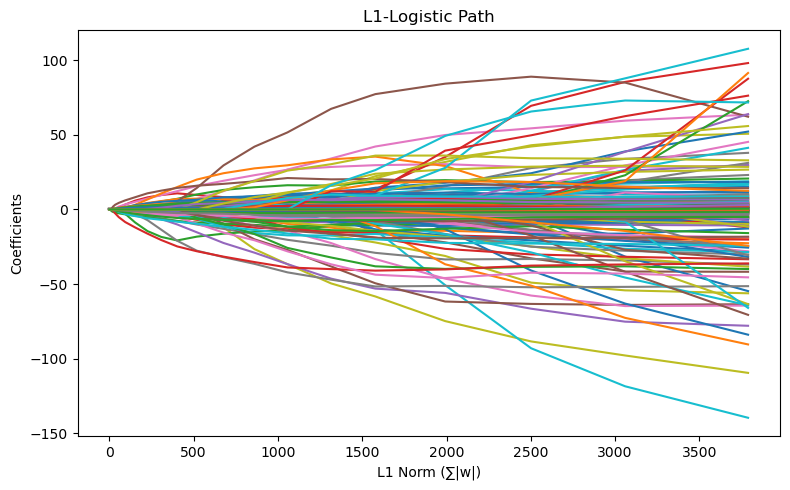

In [10]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

knn = KNNImputer(n_neighbors=10, weights='distance')
X_imputed = pd.DataFrame(knn.fit_transform(X), columns=X.columns, index=X.index)
# 1) 標準化
scaler = StandardScaler()
Xz = scaler.fit_transform(X_imputed.values)
y_arr = y.values.astype(int)
feat_names = np.array(X_imputed.columns)

Cs = np.logspace(3, -4, 40)  # C 大→懲罰弱；從弱到強掃
clf = LogisticRegressionCV(Cs=Cs, penalty='l1', solver='liblinear', cv=5, max_iter=1000, n_jobs=-1, refit=True).fit(X_imputed, y)

# 係數路徑：對 folds 取平均
paths = clf.coefs_paths_[1]          # (n_folds, len(Cs), n_features)
coef_path = paths.mean(axis=0)       # (len(Cs), n_features)

# 1) 橫軸 = L1 範數 ∑|w|
l1_norm = np.abs(coef_path).sum(axis=1)
plt.figure(figsize=(8,5))
plt.plot(l1_norm, coef_path)
plt.xlabel('L1 Norm (∑|w|)')
plt.ylabel('Coefficients')
plt.title('L1-Logistic Path')
plt.tight_layout(); plt.show()

In [12]:
best_C = float(np.ravel(clf.C_)[0])   # CV 選到的 C
best_lambda = 1.0 / best_C

print("best C =", best_C)
print("best λ =", best_lambda)

best C = 0.00022854638641349884
best λ = 4375.479375074189


In [13]:
coef = pd.Series(clf.coef_.ravel(), index=X_imputed.columns)

# 被選到的特徵＝係數 ≠ 0
selected = coef[coef != 0].sort_values(key=np.abs, ascending=False)

n_selected = int(selected.shape[0])
top10 = selected.index[:10].tolist()

print("最佳 C =", float(np.ravel(clf.C_)[0]), "→ 最佳 λ =", 1/float(np.ravel(clf.C_)[0]))
print("入選特徵數 =", n_selected)
print("前10名：", top10)

# 若想看前10的係數大小：
print(selected.iloc[:10])

最佳 C = 0.00022854638641349884 → 最佳 λ = 4375.479375074189
入選特徵數 = 9
前10名： ['x22', 'x512', 'x161', 'x91', 'x205', 'x489', 'x162', 'x25', 'x163']
x22     0.000312
x512    0.000284
x161    0.000192
x91    -0.000116
x205    0.000063
x489   -0.000040
x162   -0.000018
x25    -0.000012
x163   -0.000004
dtype: float64


In [52]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()
subX = X.loc[:, ['x22', 'x512', 'x161', 'x91', 'x205', 'x489', 'x162', 'x25', 'x163']]

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

X_train, X_test, y_train, y_test = train_test_split(subX, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# selected_by_fold = {}
all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_imputed, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_imputed)

    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.7063, FAR=0.2650
sensitivy =  33.33 %
specificity =  73.5 %
GM =  49.5 %
----------------------------------------
fold=2, acc=0.8095, FAR=0.1624
sensitivy =  44.44 %
specificity =  83.76 %
GM =  61.01 %
----------------------------------------
fold=3, acc=0.7619, FAR=0.1966
sensitivy =  22.22 %
specificity =  80.34 %
GM =  42.25 %
----------------------------------------
fold=4, acc=0.7440, FAR=0.2308
sensitivy =  37.5 %
specificity =  76.92 %
GM =  53.71 %
----------------------------------------
fold=5, acc=0.7360, FAR=0.2393
sensitivy =  37.5 %
specificity =  76.07 %
GM =  53.41 %
----------------------------------------
fold=6, acc=0.8160, FAR=0.1538
sensitivy =  37.5 %
specificity =  84.62 %
GM =  56.33 %
----------------------------------------
fold=7, acc=0.8320, FAR=0.1282
sensitivy =  25.0 %
specificity =  87.18 %
GM =  46.68 %
----------------------------------------
fold=8, acc=0.7920, FAR=0.1880
sensitivy =  50.0 %
specificity =  81.2 %
GM =  63.72 %
---------

In [ ]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

subX = X.loc[:, ['x22', 'x512', 'x161', 'x91', 'x205', 'x489', 'x162', 'x25', 'x163']]
subX = pd.concat([subX, secom[['Time', 'Pass/Fail']]], axis=1)

In [24]:
subX

,x22,x512,x161,x91,x205,x489,x162,x25,x163,Time,Pass/Fail
0,-5419.00,0.0000,967.0,8671.9301,0.2951,53.1098,1066.0,751.00,368.0,2008-07-19 11:55:00,-1
1,-5441.50,0.0000,59.0,8407.0299,0.3580,194.4371,297.0,-1640.25,3277.0,2008-07-19 12:32:00,-1
2,-5447.75,244.2748,788.0,9317.1698,0.1164,191.7582,759.0,-1916.50,2100.0,2008-07-19 13:17:00,1
3,-5468.25,0.0000,355.0,8205.7000,0.3458,0.0000,3433.0,-1657.25,3004.0,2008-07-19 14:43:00,-1
4,-5476.25,0.0000,283.0,9014.4600,0.3951,748.1781,1747.0,117.00,1443.0,2008-07-19 15:22:00,-1
...,...,...,...,...,...,...,...,...,...,...,...
1562,-5418.75,235.7895,334.0,9201.7201,0.1204,NaN,7112.0,356.00,565.0,2008-10-16 15:13:00,-1
1563,-6408.75,700.0000,94.0,8624.8599,0.1408,NaN,315.0,339.00,367.0,2008-10-16 20:49:00,-1
1564,-5153.25,0.0000,542.0,8992.6702,0.0626,NaN,3662.0,-1226.00,1355.0,2008-10-17 05:26:00,-1
1565,-5271.75,456.4103,252.0,NaN,0.0952,NaN,2702.0,394.75,1093.0,2008-10-17 06:01:00,-1


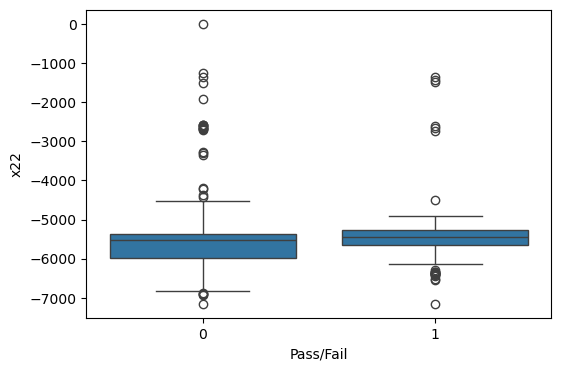

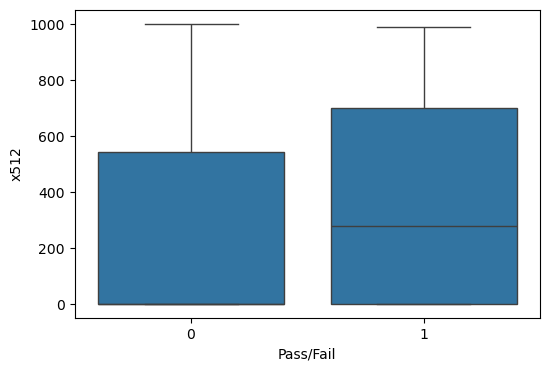

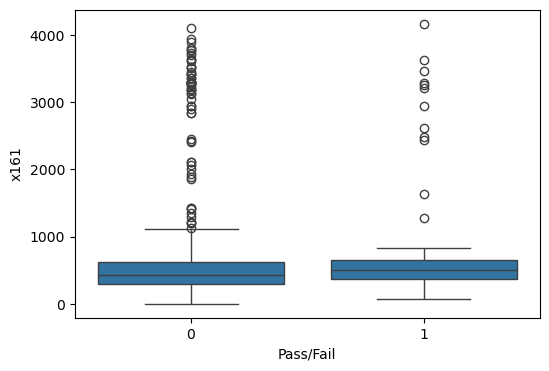

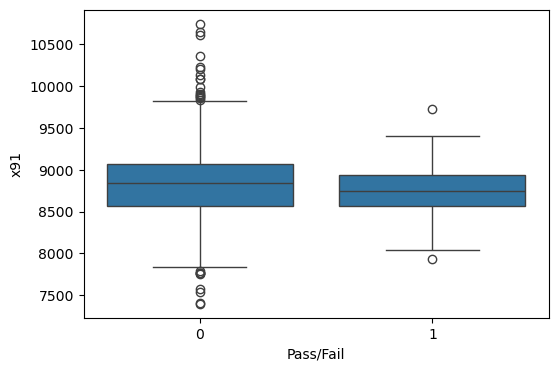

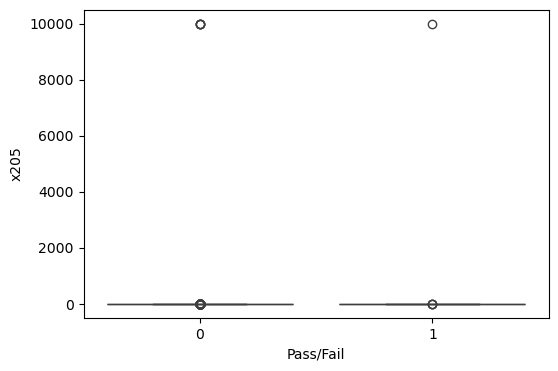

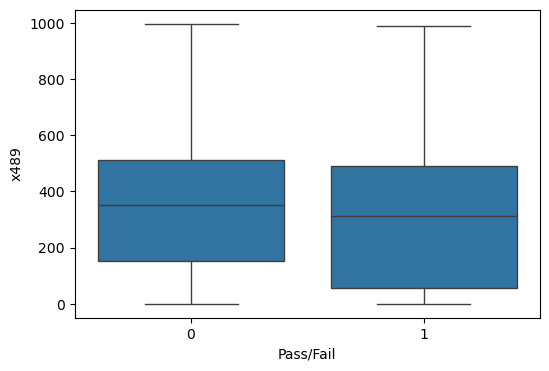

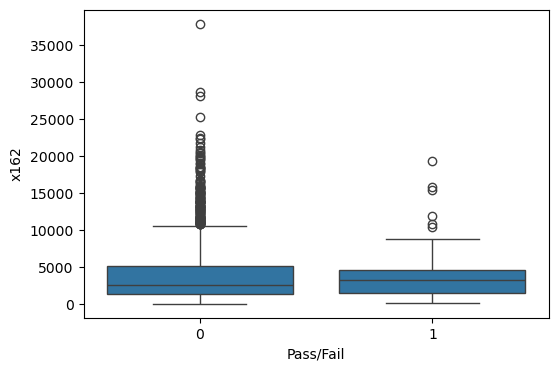

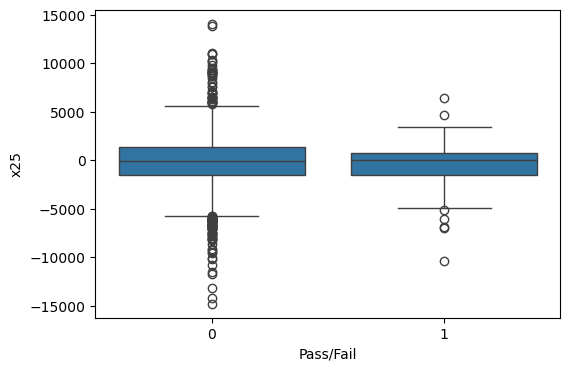

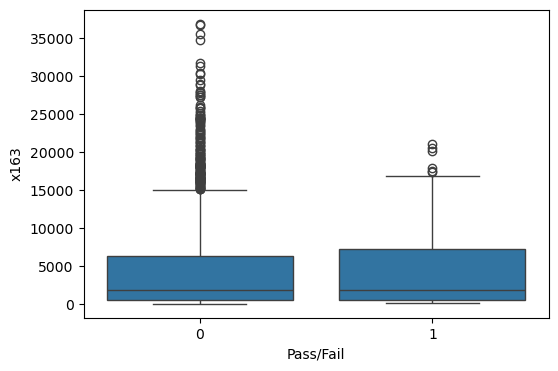

In [20]:
features = ['x22', 'x512', 'x161', 'x91', 'x205', 'x489', 'x162', 'x25', 'x163']

for col in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Pass/Fail', y=col, data=subX)
    plt.show()

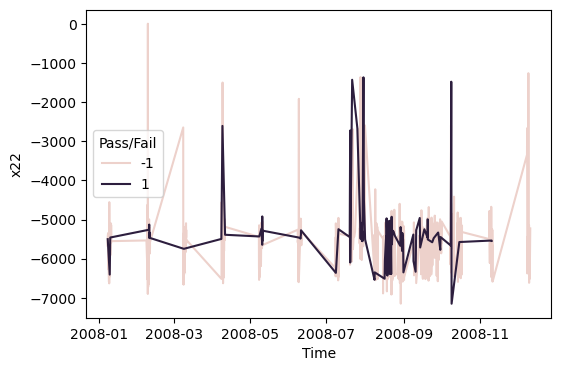

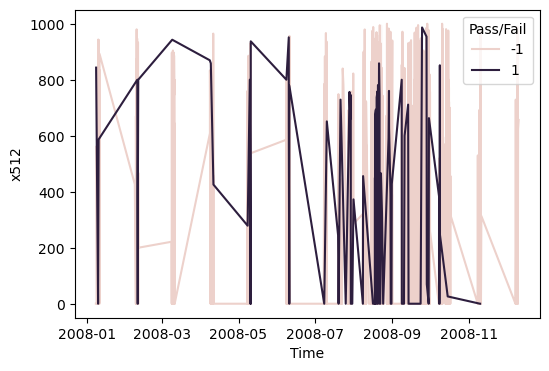

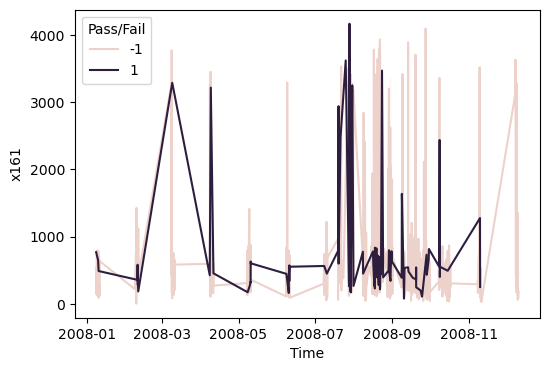

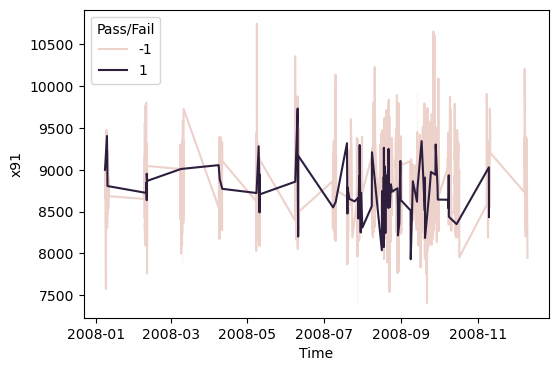

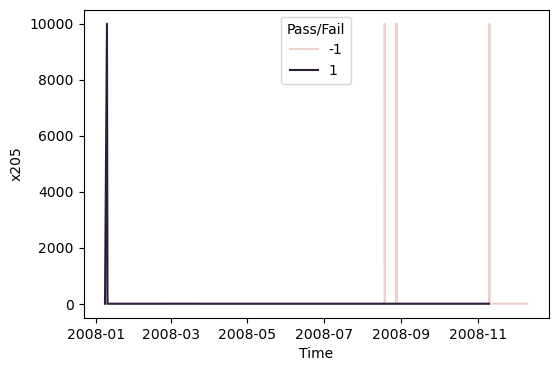

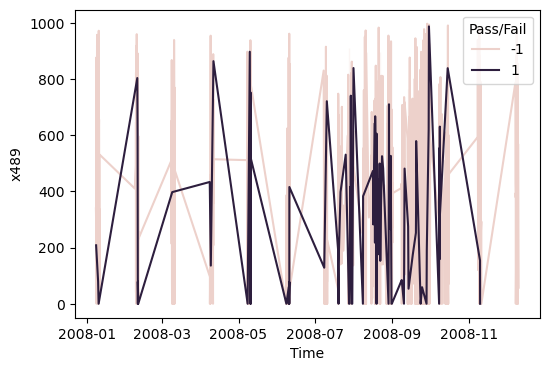

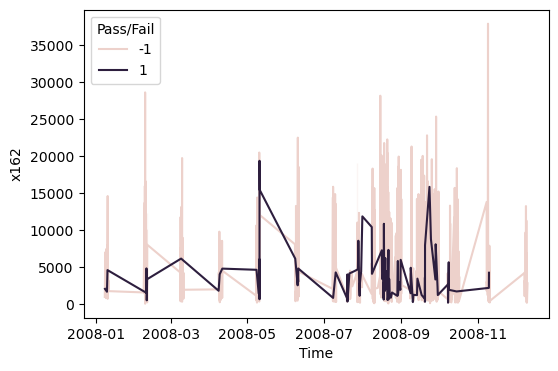

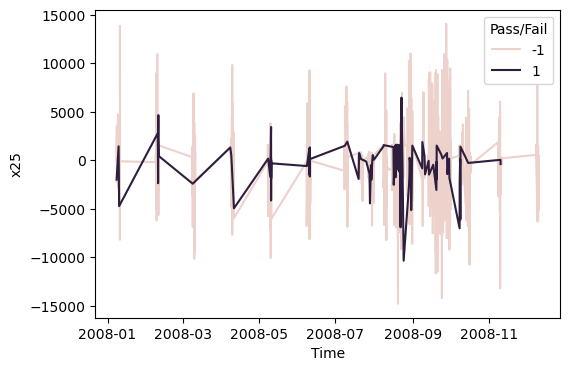

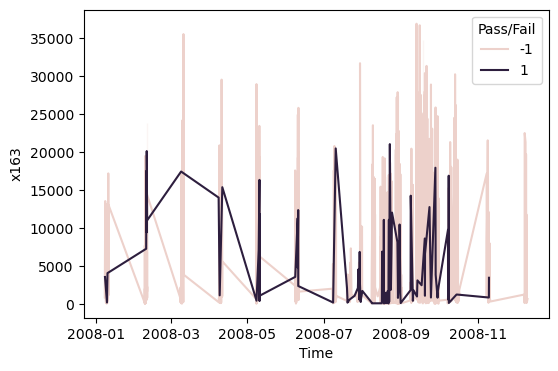

In [25]:
subX['Time'] = pd.to_datetime(subX['Time'])

features = ['x22', 'x512', 'x161', 'x91', 'x205', 'x489', 'x162', 'x25', 'x163']

for col in features:
    plt.figure(figsize=(6,4))
    sns.lineplot(x='Time', y=col, data=subX, hue='Pass/Fail')
    plt.show()

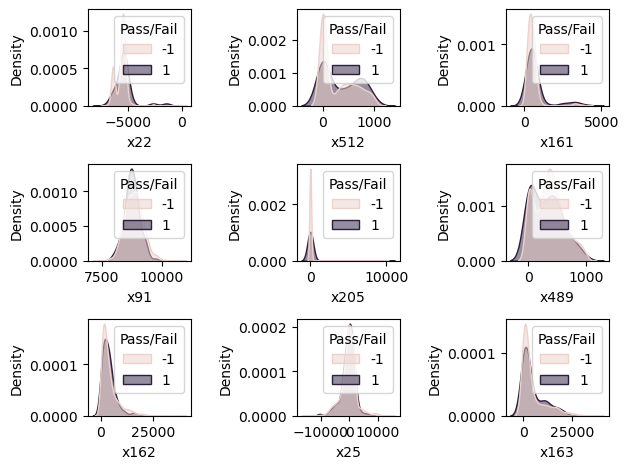

In [27]:
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)  # 3列3行子圖
    sns.kdeplot(data=subX, x=col, hue="Pass/Fail", fill=True, common_norm=False, alpha=0.5)

plt.tight_layout()
plt.show()

---
---

In [62]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def tri_class(y_proba_fail, low=0.3, high=0.7):
    """
    輸入 y_proba
    回傳 tri_class {-1:pass, 0:not sure, 1:Fail}
    """
    if not (0<=low<high<=1):
        raise ValueError('low必須<high, 且都在[0, 1]')
    tri = np.where(y_proba_fail<=low, -1, np.where(y_proba_fail>=high,1 ,0))
    return tri

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

selected_by_fold = {}
all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_imputed, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    selected_by_fold[fold] = selected

    coef_sel = coef.loc[selected]
    df_rank = (pd.DataFrame({"feature": coef_sel.index, "coef": coef_sel.values}).assign(l1_abs=lambda d: d["coef"].abs()).sort_values("l1_abs", ascending=False).reset_index(drop=True))
    df_rank["rank_l1_abs"] = np.arange(1, len(df_rank)+1)

    if fold == 6:
        print(f"[Fold 6] selected features = {len(selected)}")
        print("[Fold 6] order by |coef| (descending):")
        print(df_rank[["rank_l1_abs","feature","coef","l1_abs"]].head(30).to_string(index=False))
        print("（排序標準：|L1 係數| 由大到小）")

    X_tr_selected = X_tr_imputed[selected].copy()
    X_te_selected = X_te_imputed[selected].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_selected, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_selected)

    if fold == 6:
        y_prob = rf.predict_proba(X_te_selected)[:, 1]
        tri = tri_class(y_prob, low=0.3, high=0.7)
        out = pd.DataFrame({"y_true": y_te.values, "y_pred_bin": y_pred, "p_fail": y_prob, "tri_class": tri}, index=X_te_selected.index)
        print(out.head())
        print("tri_class counts:\n", out["tri_class"].value_counts().sort_index())
        
        y_true_s = y_te.rename("y_true")
        y_pred_s = pd.Series(y_pred, index=X_te_selected.index, name="y_pred")
        fold6_secom_result = pd.concat([X_te_selected, y_true_s, y_pred_s], axis=1)
        print(fold6_secom_result.head(1))
        fold6_secom_test = secom.loc[X_te_selected.index].copy()
        fold6_secom_test["y_true"] = y_true_s
        fold6_secom_test["y_pred"] = y_pred_s
        print(confusion_matrix(y_te, y_pred, labels=[0, 1]))
        
    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8651, FAR=0.0684
sensitivy =  0.0 %
specificity =  93.16 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9048, FAR=0.0513
sensitivy =  33.33 %
specificity =  94.87 %
GM =  56.24 %
----------------------------------------
fold=3, acc=0.8730, FAR=0.0684
sensitivy =  11.11 %
specificity =  93.16 %
GM =  32.17 %
----------------------------------------
fold=4, acc=0.9040, FAR=0.0598
sensitivy =  37.5 %
specificity =  94.02 %
GM =  59.38 %
----------------------------------------
fold=5, acc=0.9200, FAR=0.0342
sensitivy =  25.0 %
specificity =  96.58 %
GM =  49.14 %
----------------------------------------
[Fold 6] selected features = 183
[Fold 6] order by |coef| (descending):
 rank_l1_abs feature      coef   l1_abs
           1    x446  2.168428 2.168428
           2    x178 -1.616071 1.616071
           3    x334  1.588997 1.588997
           4    x407  0.857853 0.857853
           5    x337 -0.711831 0.711831
           6     x15 -0.653757 0.653757
    

In [67]:
secom = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\DataSet\secom.csv', sep='\t')
np.random.seed(42)
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts<=550].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts>=50].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN, FP],[FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

def tri_class(y_proba_fail, low=0.3, high=0.7):
    """
    輸入 y_proba
    回傳 tri_class {-1:pass, 0:not sure, 1:Fail}
    """
    if not (0<=low<high<=1):
        raise ValueError('low必須<high, 且都在[0, 1]')
    tri = np.where(y_proba_fail<=low, -1, np.where(y_proba_fail>=high,1 ,0))
    return tri

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

selected_by_fold = {}
all_metrics = []
for fold, (tr_idx, te_idx) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
    y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

    knn = KNNImputer(n_neighbors=10, weights='distance')
    X_tr_imputed = pd.DataFrame(knn.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
    X_te_imputed = pd.DataFrame(knn.transform(X_te), columns=X_te.columns, index=X_te.index)

    scaler = StandardScaler(with_mean=True, with_std=True)
    X_tr_z = pd.DataFrame(scaler.fit_transform(X_tr_imputed), columns=X_tr_imputed.columns, index=X_tr_imputed.index)
    X_te_z = pd.DataFrame(scaler.transform(X_te_imputed), columns=X_te_imputed.columns, index=X_te_imputed.index)

    l1 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
    l1.fit(X_tr_z, y_tr)

    coef = pd.Series(l1.coef_.ravel(), index=X_tr_imputed.columns)
    selected = coef[coef != 0].index.tolist()
    if len(selected) == 0:
        selected = list(X_tr_imputed.columns)

    selected_by_fold[fold] = selected

    coef_sel = coef.loc[selected]
    df_rank = (pd.DataFrame({"feature": coef_sel.index, "coef": coef_sel.values}).assign(l1_abs=lambda d: d["coef"].abs()).sort_values("l1_abs", ascending=False).reset_index(drop=True))
    df_rank["rank_l1_abs"] = np.arange(1, len(df_rank)+1)

    if fold == 6:
        l1_raw = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, max_iter=2000, random_state=42)
        l1_raw.fit(X_tr_imputed, y_tr)
        coef_raw = pd.Series(l1_raw.coef_.ravel(), index=X_tr_imputed.columns)
        selected_raw = set(coef_raw[coef_raw != 0].index.tolist()) or set(X_tr_imputed.columns)

        selected_z = set(selected)
        print(f"[Fold 6] selected(feat) with Z-score = {len(selected_z)}, without = {len(selected_raw)}")
        print("[Fold 6] in Z-score only (新增於標準化):", list(selected_z - selected_raw)[:20])
        print("[Fold 6] dropped after Z-score (未標準化才會入選):", list(selected_raw - selected_z)[:20])

        print("\n[Fold 6] order by |L1 coef| after Z-score（前30）")
        print(df_rank[["rank_l1_abs","feature","coef","l1_abs"]].head(30).to_string(index=False))
        print("（排序標準：|L1 係數| 由大到小；係數來自標準化後之模型）\n")

    X_tr_selected = X_tr_imputed[selected].copy()
    X_te_selected = X_te_imputed[selected].copy()

    smote = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=42)
    X_balanced, y_balanced = smote.fit_resample(X_tr_selected, y_tr)

    rf = RandomForestClassifier(n_estimators=1000, min_samples_leaf=15, max_depth=6, min_samples_split=20, random_state=42, n_jobs=-1)
    rf.fit(X_balanced, y_balanced)
    y_pred = rf.predict(X_te_selected)

    if fold == 6:
        y_prob = rf.predict_proba(X_te_selected)[:, 1]
        tri = tri_class(y_prob, low=0.3, high=0.7)
        out = pd.DataFrame({"y_true": y_te.values, "y_pred_bin": y_pred, "p_fail": y_prob, "tri_class": tri}, index=X_te_selected.index)
        print(out.head())
        print("tri_class counts:\n", out["tri_class"].value_counts().sort_index())
        
        y_true_s = y_te.rename("y_true")
        y_pred_s = pd.Series(y_pred, index=X_te_selected.index, name="y_pred")
        fold6_secom_result = pd.concat([X_te_selected, y_true_s, y_pred_s], axis=1)
        print(fold6_secom_result.head(1))
        fold6_secom_test = secom.loc[X_te_selected.index].copy()
        fold6_secom_test["y_true"] = y_true_s
        fold6_secom_test["y_pred"] = y_pred_s
        print(confusion_matrix(y_te, y_pred, labels=[0, 1]))
        
    m = compute_metrics(y_te.values, y_pred)
    all_metrics.append(m)

    print(f"fold={fold}, acc={m['acc']:.4f}, FAR={m['FAR']:.4f}")
    print("sensitivy = ", round(m["sensitivity"]*100, 2), "%")
    print("specificity = ", round(m["specificity"]*100, 2), "%")
    print("GM = ", round(m["GM"]*100, 2), "%")
    print("-"*40)

avg = {k: np.nanmean([m[k] for m in all_metrics]) for k in ["acc","FAR","sensitivity","specificity","GM"]}
print("[Mean over 10 folds]")
print(f"acc={avg['acc']:.4f}, FAR={avg['FAR']:.4f}")
print("sensitivy = ", round(avg["sensitivity"]*100, 2), "%")
print("specificity = ", round(avg["specificity"]*100, 2), "%")
print("GM = ", round(avg["GM"]*100, 2), "%")

fold=1, acc=0.8413, FAR=0.0940
sensitivy =  0.0 %
specificity =  90.6 %
GM =  0.0 %
----------------------------------------
fold=2, acc=0.9127, FAR=0.0342
sensitivy =  22.22 %
specificity =  96.58 %
GM =  46.33 %
----------------------------------------
fold=3, acc=0.8730, FAR=0.0684
sensitivy =  11.11 %
specificity =  93.16 %
GM =  32.17 %
----------------------------------------
fold=4, acc=0.8880, FAR=0.0598
sensitivy =  12.5 %
specificity =  94.02 %
GM =  34.28 %
----------------------------------------
fold=5, acc=0.8880, FAR=0.0598
sensitivy =  12.5 %
specificity =  94.02 %
GM =  34.28 %
----------------------------------------
[Fold 6] selected(feat) with Z-score = 188, without = 183
[Fold 6] in Z-score only (新增於標準化): ['x311', 'x27', 'x589', 'x356', 'x444', 'x456', 'x126', 'x156', 'x48', 'x146', 'x496', 'x57', 'x78', 'x559', 'x61', 'x83', 'x350', 'x54', 'x355', 'x79']
[Fold 6] dropped after Z-score (未標準化才會入選): ['x2', 'x521', 'x570', 'x297', 'x52', 'x435', 'x523', 'x295', 'x484'